# Moran Process Fixation Probability -- Library Demo

**Moran process**: a population of $N$ individuals on a graph, one mutant with fitness $r$ vs $N-1$ residents (fitness 1). Birth-Death update: select reproducer proportional to fitness, replace a uniform random neighbor.

**Fixation probability** $\rho(G, r)$: probability the mutant takes over.

This notebook demonstrates `libmoran` -- exact formulas, naive Monte Carlo (Diaz et al. 2014), graph interop, and parameter derivation.

In [1]:
import sys, pathlib

_root = pathlib.Path.cwd()
if _root.name == 'notebooks':
    _root = _root.parent
sys.path.insert(0, str(_root / 'python'))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import moran
from moran import fixation_probability, exact
from moran.graph import CSRGraph, complete_graph, cycle_graph, star_graph, double_star_graph
from moran.algorithms import naive
from moran._moran import algorithms as _alg

pd.set_option('display.width', 160)
plt.rcParams.update({'figure.dpi': 130, 'axes.grid': True, 'grid.alpha': 0.3})

COLORS = {'complete': '#1f77b4', 'cycle': '#2ca02c', 'star': '#d62728', 'dbl_star': '#9467bd'}

print(f'libmoran {moran.__version__}')

libmoran 0.1.0


## 1. Graph zoo

Built-in generators: complete ($K_n$), cycle ($C_n$), star ($S_n$), double star ($DS_{a,b}$).

In [3]:
N_VIS = 12
zoo = {
    'complete':  complete_graph(N_VIS),
    'cycle':     cycle_graph(N_VIS),
    'star':      star_graph(N_VIS),
    'dbl_star':  double_star_graph(N_VIS // 2, N_VIS // 2),
}

rows = []
for name, g in zoo.items():
    ds = g.degree_stats()
    rows.append({'graph': name, 'n': g.num_vertices(), 'm': g.num_edges(),
                 'min_deg': ds.min_degree, 'max_deg': ds.max_degree,
                 'regular': ds.is_regular, 'connected': g.is_connected()})
pd.DataFrame(rows)

,graph,n,m,min_deg,max_deg,regular,connected
0,complete,12,66,11,11,True,True
1,cycle,12,12,2,2,True,True
2,star,12,11,1,11,False,True
3,dbl_star,14,13,1,7,False,True


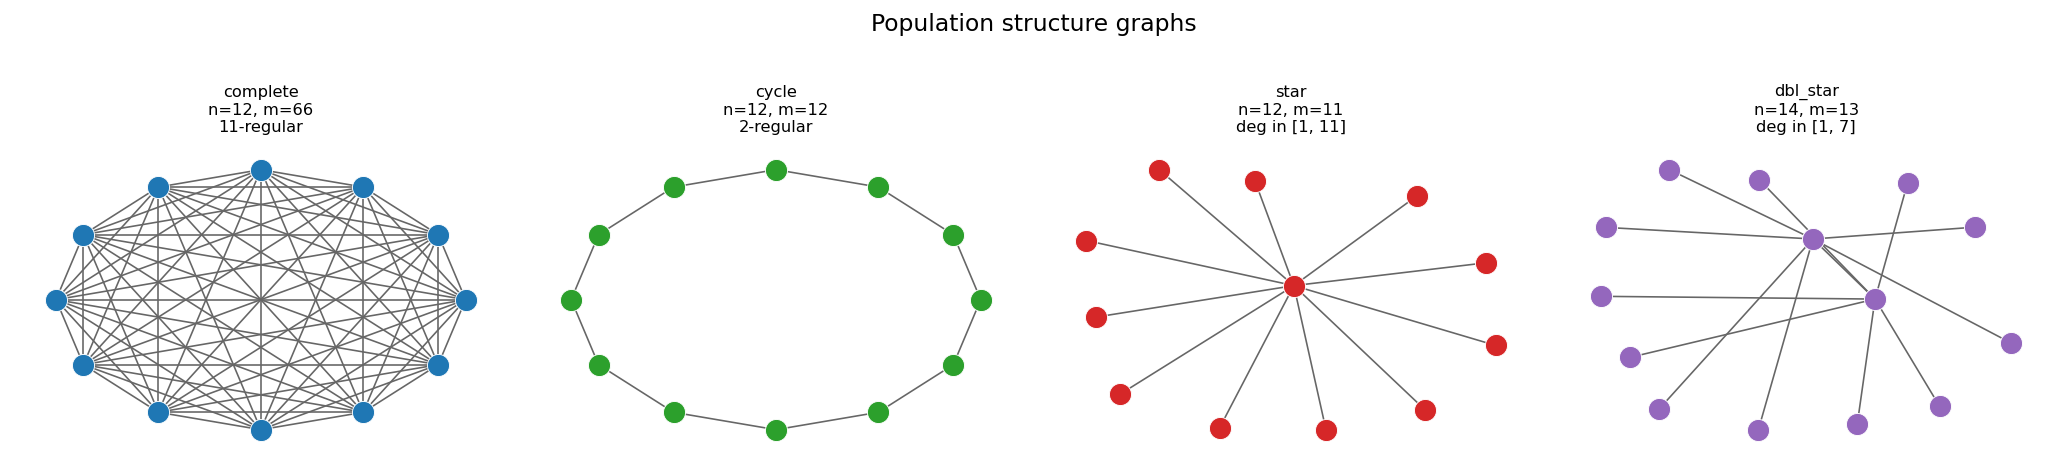

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

layouts = {
    'complete':  lambda G: nx.shell_layout(G),
    'cycle':     lambda G: nx.circular_layout(G),
    'star':      lambda G: nx.spring_layout(G, seed=42, k=2.0),
    'dbl_star':  lambda G: nx.spring_layout(G, seed=42, k=2.0),
}

for ax, (name, g) in zip(axes, zoo.items()):
    G_nx = g.to_networkx()
    pos = layouts[name](G_nx)
    nx.draw(G_nx, pos, ax=ax, node_size=150, node_color=COLORS[name],
            edge_color='#666', width=0.9, with_labels=False,
            edgecolors='white', linewidths=0.5)
    ds = g.degree_stats()
    label = f'{name}\nn={g.num_vertices()}, m={g.num_edges()}'
    if ds.is_regular:
        label += f'\n{ds.min_degree}-regular'
    else:
        label += f'\ndeg in [{ds.min_degree}, {ds.max_degree}]'
    ax.set_title(label, fontsize=9)

plt.suptitle('Population structure graphs', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 2. Exact formulas

- Well-mixed: $\rho = (1 - 1/r) / (1 - 1/r^N)$, neutral ($r=1$): $\rho = 1/N$
- **Isothermal theorem** (Lieberman et al. 2005): regular graphs have identical $\rho$ to well-mixed
- `fixation_probability_from(N, i0, r)`: fixation starting from $i_0$ mutants

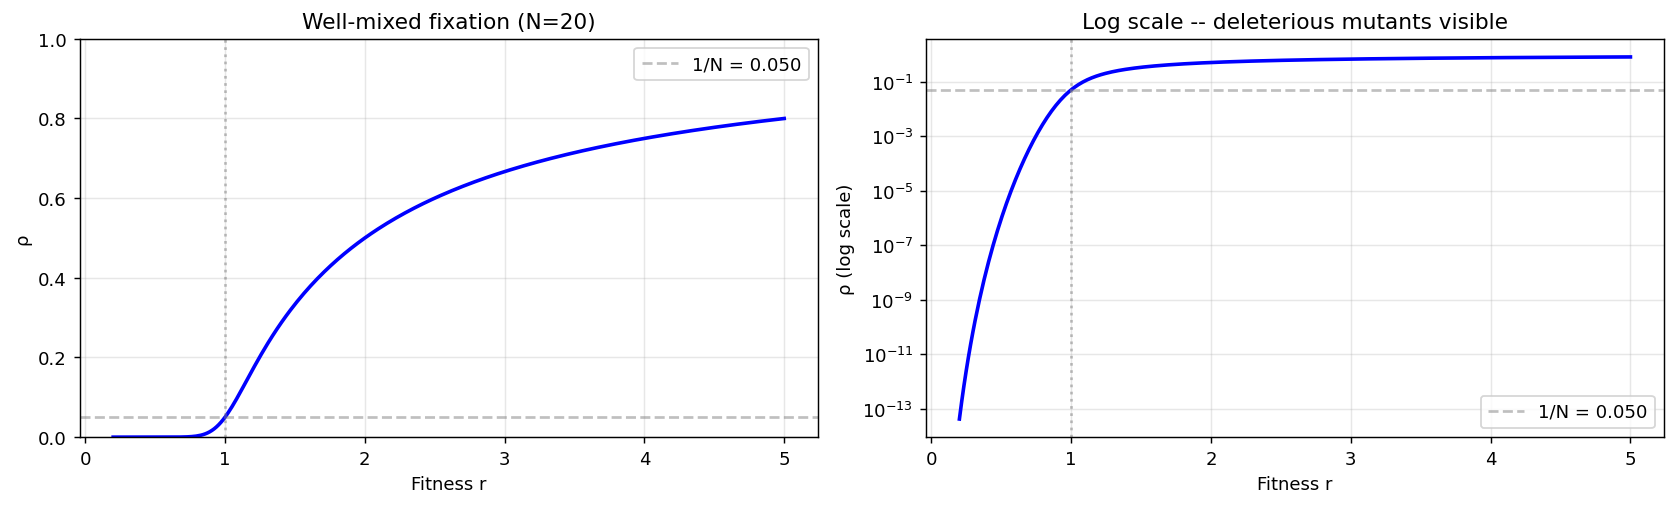

In [5]:
N = 20
r_grid = np.linspace(0.2, 5.0, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
rho = [exact.well_mixed(N, float(r)) for r in r_grid]

ax1.plot(r_grid, rho, 'b-', lw=2)
ax1.axhline(1/N, color='gray', ls='--', alpha=.5, label=f'1/N = {1/N:.3f}')
ax1.axvline(1.0, color='gray', ls=':', alpha=.5)
ax1.set(xlabel='Fitness r', ylabel='\u03c1', title=f'Well-mixed fixation (N={N})', ylim=(0, 1))
ax1.legend()

ax2.plot(r_grid, rho, 'b-', lw=2)
ax2.axhline(1/N, color='gray', ls='--', alpha=.5, label=f'1/N = {1/N:.3f}')
ax2.axvline(1.0, color='gray', ls=':', alpha=.5)
ax2.set(xlabel='Fitness r', ylabel='\u03c1 (log scale)', title='Log scale -- deleterious mutants visible')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout(); plt.show()

In [6]:
# Isothermal theorem: regular graphs have the same fixation probability
pd.DataFrame([{
    'r': r,
    'well_mixed': f'{exact.well_mixed(N, r):.10f}',
    'isothermal_regular': f'{exact.isothermal_regular(N, r):.10f}',
    'match': exact.well_mixed(N, r) == exact.isothermal_regular(N, r),
} for r in [0.5, 1.0, 1.5, 2.0, 5.0]])

,r,well_mixed,isothermal_regular,match
0,0.5,0.0000009537,0.0000009537,True
1,1.0,0.0500000000,0.0500000000,True
2,1.5,0.3334336064,0.3334336064,True
3,2.0,0.5000004768,0.5000004768,True
4,5.0,0.8000000000,0.8000000000,True


In [7]:
# try_exact: returns FixationResult for regular/neutral graphs, None otherwise
print(f'Cycle (regular):   {exact.try_exact(cycle_graph(20), 1.5)}')
print(f'Star  (irregular): {exact.try_exact(star_graph(20), 1.5)}')
print()

# fixation_probability_from: starting from i0 mutants
wm = _alg.wellmixed
print(f'rho(N=10, i0=0, r=1.5) = {wm.fixation_probability_from(10, 0, 1.5):.6f}  (boundary: 0)')
print(f'rho(N=10, i0=1, r=1.5) = {wm.fixation_probability_from(10, 1, 1.5):.6f}  (standard)')
print(f'rho(N=10, i0=5, r=1.5) = {wm.fixation_probability_from(10, 5, 1.5):.6f}  (halfway)')
print(f'rho(N=10, i0=10,r=1.5) = {wm.fixation_probability_from(10, 10, 1.5):.6f} (boundary: 1)')

Cycle (regular):   FixationResult(estimate=0.333434, CI=[0.333434, 0.333434], method=exact_isothermal_regular, samples=0, elapsed=0.000s)
Star  (irregular): None

rho(N=10, i0=0, r=1.5) = 0.000000  (boundary: 0)
rho(N=10, i0=1, r=1.5) = 0.339216  (standard)
rho(N=10, i0=5, r=1.5) = 0.883636  (halfway)
rho(N=10, i0=10,r=1.5) = 1.000000 (boundary: 1)


## 3. Population size effect

$N \to \infty$: $\rho \to 1 - 1/r$ for $r > 1$.

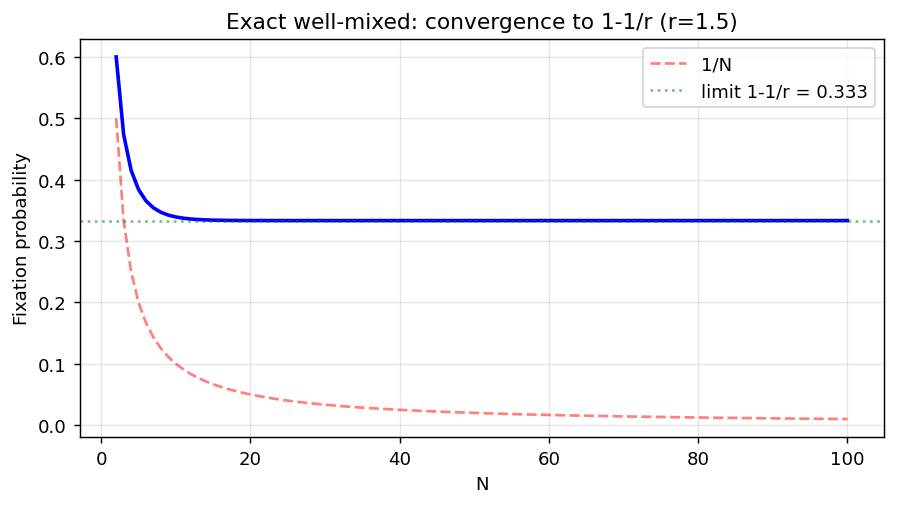

In [8]:
r = 1.5
N_range = np.arange(2, 101)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(N_range, [exact.well_mixed(int(n), r) for n in N_range], 'b-', lw=2)
ax.plot(N_range, [1/n for n in N_range], 'r--', alpha=.5, label='1/N')
ax.axhline(1 - 1/r, color='g', ls=':', alpha=.5, label=f'limit 1-1/r = {1-1/r:.3f}')
ax.set(xlabel='N', ylabel='Fixation probability',
       title=f'Exact well-mixed: convergence to 1-1/r (r={r})')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Naive MC vs exact

Complete and cycle are regular -- naive MC should match the exact formula.
Star and double star are irregular -- MC is the only option.

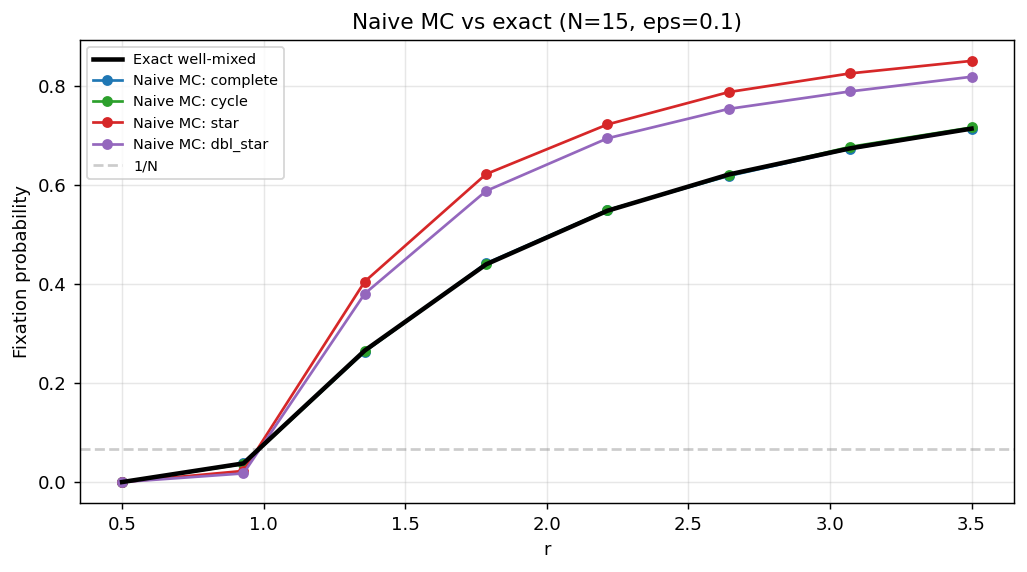

In [9]:
N = 15
r_grid = np.linspace(0.5, 3.5, 8)
exact_wm = [exact.well_mixed(N, float(r)) for r in r_grid]

graphs = {
    'complete': complete_graph(N),
    'cycle':    cycle_graph(N),
    'star':     star_graph(N),
    'dbl_star': double_star_graph(N // 2, N - N // 2),
}

mc = {}
for name, g in graphs.items():
    mc[name] = [naive.estimate(g, float(r), epsilon=0.1, seed=42, num_threads=0).estimate
                for r in r_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(r_grid, exact_wm, 'k-', lw=2.5, label='Exact well-mixed', zorder=5)
for name, est in mc.items():
    ax.plot(r_grid, est, 'o-', ms=5, color=COLORS[name], label=f'Naive MC: {name}')
ax.axhline(1/N, color='gray', ls='--', alpha=.4, label='1/N')
ax.set(xlabel='r', ylabel='Fixation probability',
       title=f'Naive MC vs exact (N={N}, eps=0.1)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

The Diaz FPRAS guarantees *multiplicative* error $|\hat\rho - \rho| \le \varepsilon \cdot \rho$.
For $r < 1$, $\rho \approx r^N \to 0$ exponentially, so even a tiny additive error gives huge relative error.

In [10]:
N = 15
comp_rows = []
for r in [0.5, 1.0, 1.5, 2.0, 3.0]:
    ex = exact.well_mixed(N, r)
    mc_K = naive.estimate(complete_graph(N), r, epsilon=0.1, seed=42, num_threads=0)
    mc_S = naive.estimate(star_graph(N), r, epsilon=0.1, seed=42, num_threads=0)
    mc_D = naive.estimate(double_star_graph(N // 2, N - N // 2), r, epsilon=0.1, seed=42, num_threads=0)
    comp_rows.append({
        'r': r, 'exact_wm': f'{ex:.6f}',
        'MC_complete': f'{mc_K.estimate:.6f}',
        'MC_star': f'{mc_S.estimate:.6f}',
        'MC_dbl_star': f'{mc_D.estimate:.6f}',
    })
pd.DataFrame(comp_rows)

,r,exact_wm,MC_complete,MC_star,MC_dbl_star
0,0.5,0.000031,0.000032,0.000000,0.000000
1,1.0,0.066667,0.065305,0.068896,0.058631
2,1.5,0.334096,0.333643,0.499166,0.471071
3,2.0,0.500015,0.501090,0.680367,0.645143
4,3.0,0.666667,0.665972,0.824410,0.783971


## 5. Epsilon sweep -- cost vs accuracy

Derived parameters show how $\varepsilon$ controls sample count and step budget.

In [11]:
g = complete_graph(20)
r = 1.5
exact_val = exact.well_mixed(20, r)

eps_grid = [0.30, 0.20, 0.15, 0.10, 0.07]
eps_rows = []
for eps in eps_grid:
    params = _alg.params.diaz_naive(20, r, epsilon=eps)
    res = naive.estimate(g, r, epsilon=eps, seed=42, num_threads=1)
    eps_rows.append({'epsilon': eps, 'estimate': res.estimate,
                     'ci_lower': res.ci_lower, 'ci_upper': res.ci_upper,
                     'samples': params.samples,
                     'step_limit': params.per_run_step_limit,
                     'steps_total': res.steps_total,
                     'time_s': f'{res.elapsed_seconds:.3f}',
                     'rel_error': f'{abs(res.estimate - exact_val) / exact_val:.2%}'})

df_eps = pd.DataFrame(eps_rows)
df_eps

,epsilon,estimate,ci_lower,ci_upper,samples,step_limit,steps_total,time_s,rel_error
0,0.30,0.334469,0.257284,0.477813,6162,1920000,549337,0.104,0.31%
1,0.20,0.331025,0.275854,0.413781,13863,1920000,1231967,0.231,0.72%
2,0.15,0.332468,0.289102,0.391139,24646,1920000,2213435,0.412,0.29%
3,0.10,0.330538,0.300489,0.367265,55452,1920000,4951816,0.918,0.87%
4,0.07,0.332659,0.310896,0.357698,113167,1920000,10168207,1.889,0.23%


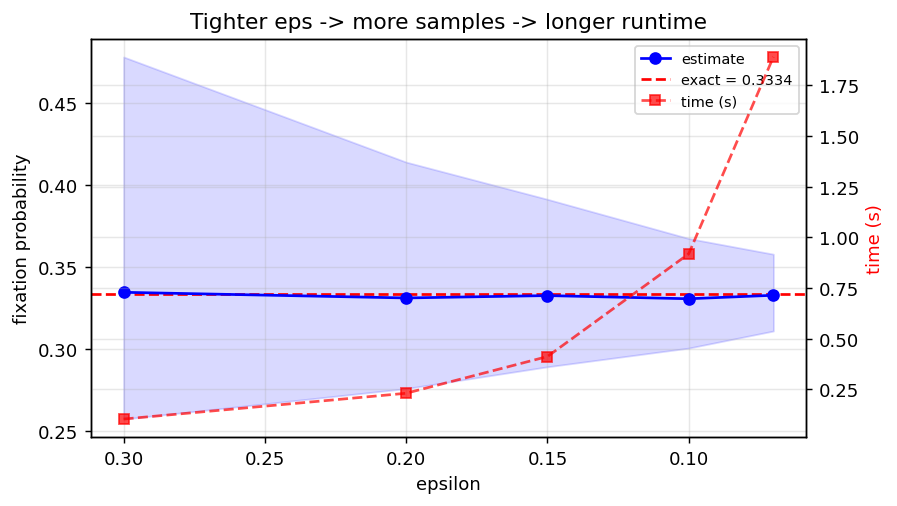

In [12]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(df_eps['epsilon'], df_eps['estimate'], 'bo-', label='estimate', zorder=5)
ax1.fill_between(df_eps['epsilon'], df_eps['ci_lower'], df_eps['ci_upper'],
                 alpha=.15, color='b')
ax1.axhline(exact_val, color='r', ls='--', lw=1.5, label=f'exact = {exact_val:.4f}')
ax1.set(xlabel='epsilon', ylabel='fixation probability')
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.plot(df_eps['epsilon'], [float(t) for t in df_eps['time_s']], 'rs--', alpha=.7, label='time (s)')
ax2.set_ylabel('time (s)', color='r')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8)
ax1.set_title('Tighter eps -> more samples -> longer runtime')
plt.tight_layout(); plt.show()

## 6. Ineffective steps

If reproducer and replaced vertex have the same type, the step is wasted.
Naive MC simulates all of them -- this is the main cost driver.

In [13]:
sizes = [8, 12, 16, 20, 25]
graph_types = ['complete', 'cycle', 'star', 'dbl_star']

def make_graph(name, n):
    if name == 'complete':  return complete_graph(n)
    if name == 'cycle':     return cycle_graph(n)
    if name == 'star':      return star_graph(n)
    if name == 'dbl_star':  return double_star_graph(n // 2, n - n // 2)

eff_rows = []
for n in sizes:
    for name in graph_types:
        g = make_graph(name, n)
        res = naive.estimate(g, 1.5, epsilon=0.15, seed=42, num_threads=0)
        wasted = 1 - res.steps_effective / max(res.steps_total, 1)
        eff_rows.append({'graph': name, 'N': n,
                         'steps_total': res.steps_total,
                         'steps_effective': res.steps_effective,
                         'wasted_frac': wasted, 'time_s': res.elapsed_seconds})

df_eff = pd.DataFrame(eff_rows)
df_eff.pivot_table(index='N', columns='graph', values='wasted_frac').round(3)

graph,complete,cycle,dbl_star,star
N,,,,
8,0.587,0.742,0.825,0.649
12,0.637,0.831,0.859,0.685
16,0.666,0.872,0.879,0.708
20,0.686,0.898,0.894,0.723
25,0.703,0.919,0.906,0.737


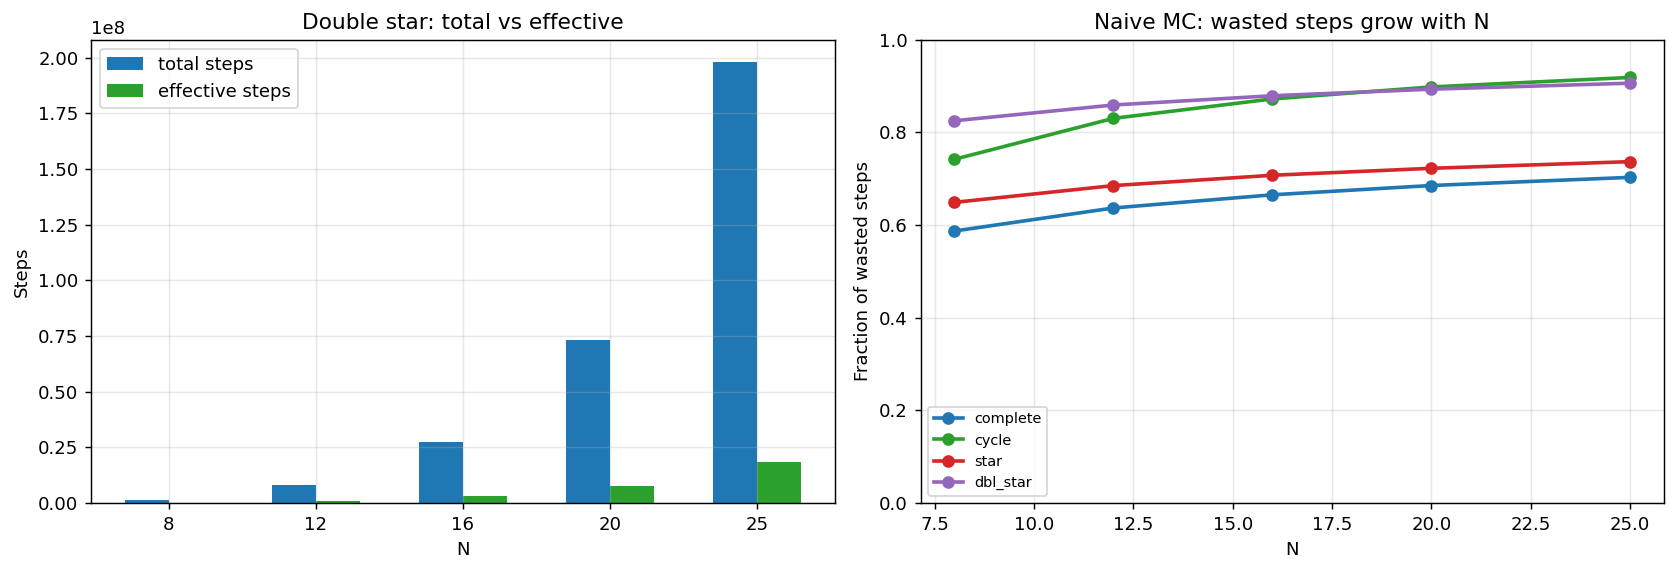

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: total vs effective steps for double star
sub = df_eff[df_eff['graph'] == 'dbl_star']
x = np.arange(len(sub))
ax1.bar(x - 0.15, sub['steps_total'], 0.3, color='C0', label='total steps')
ax1.bar(x + 0.15, sub['steps_effective'], 0.3, color='C2', label='effective steps')
ax1.set_xticks(x, labels=sub['N'].values)
ax1.set(xlabel='N', ylabel='Steps', title='Double star: total vs effective')
ax1.legend()

# Right: wasted fraction across graph types
for name in graph_types:
    sub = df_eff[df_eff['graph'] == name]
    ax2.plot(sub['N'], sub['wasted_frac'], 'o-', color=COLORS[name],
             lw=2, ms=6, label=name)
ax2.set(xlabel='N', ylabel='Fraction of wasted steps',
        title='Naive MC: wasted steps grow with N', ylim=(0, 1))
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Runtime scaling

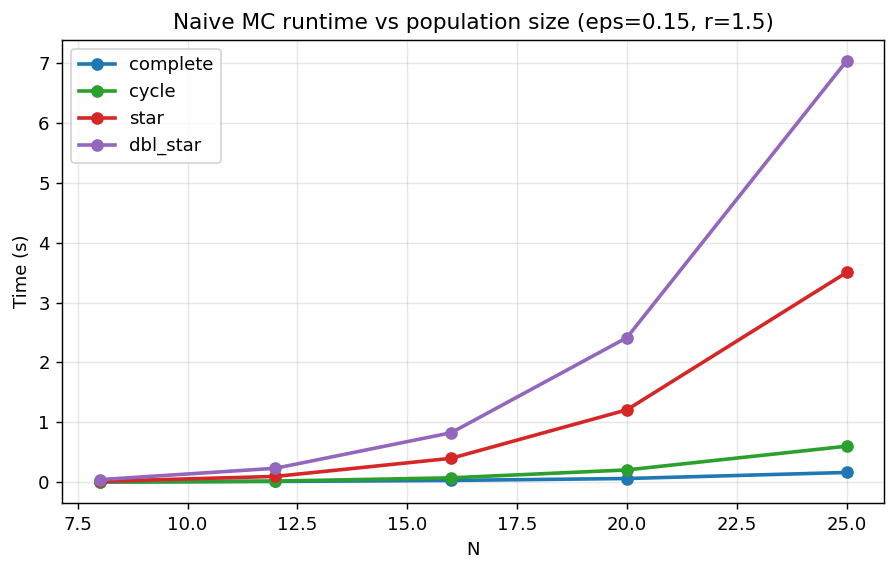

In [15]:
# Time vs N for different graph structures
fig, ax = plt.subplots(figsize=(7, 4.5))
for name in graph_types:
    sub = df_eff[df_eff['graph'] == name]
    ax.plot(sub['N'], sub['time_s'], 'o-', color=COLORS[name],
            lw=2, ms=6, label=name)
ax.set(xlabel='N', ylabel='Time (s)',
       title='Naive MC runtime vs population size (eps=0.15, r=1.5)')
ax.legend(); plt.tight_layout(); plt.show()

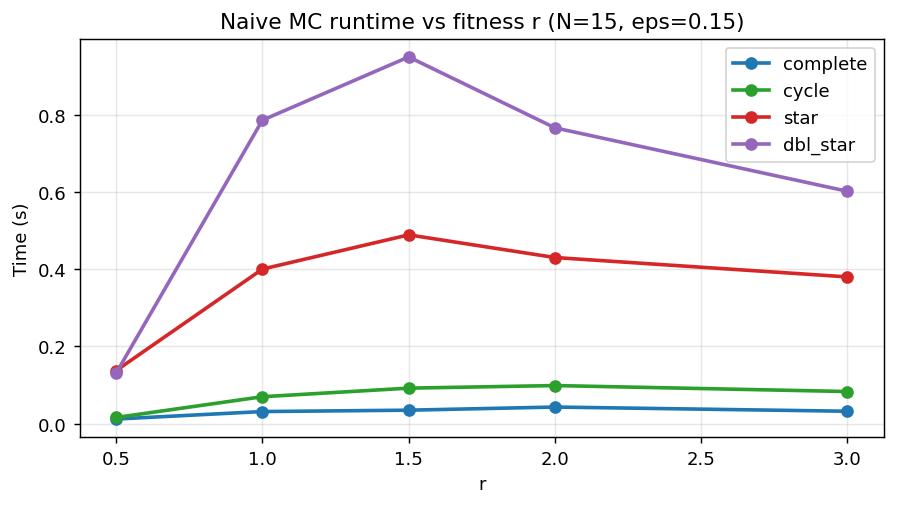

In [16]:
r_grid_time = [0.5, 1.0, 1.5, 2.0, 3.0]
N = 15

time_rows = []
for r in r_grid_time:
    for name in graph_types:
        g = make_graph(name, N)
        res = naive.estimate(g, r, epsilon=0.15, seed=42, num_threads=0)
        time_rows.append({'r': r, 'graph': name, 'time_s': res.elapsed_seconds,
                          'steps_total': res.steps_total})

df_time_r = pd.DataFrame(time_rows)

fig, ax = plt.subplots(figsize=(7, 4))
for name in graph_types:
    sub = df_time_r[df_time_r['graph'] == name]
    ax.plot(sub['r'], sub['time_s'], 'o-', color=COLORS[name], lw=2, ms=6, label=name)
ax.set(xlabel='r', ylabel='Time (s)',
       title=f'Naive MC runtime vs fitness r (N={N}, eps=0.15)')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Thread scaling

In [17]:
import multiprocessing
max_threads = min(multiprocessing.cpu_count(), 16)
thread_counts = sorted(set([1, 2, 4, max_threads]))

g = complete_graph(25)

thread_rows = []
for t in thread_counts:
    res = naive.estimate(g, 1.5, epsilon=0.1, seed=42, num_threads=t)
    thread_rows.append({'threads': t, 'time_s': res.elapsed_seconds,
                        'samples': res.samples, 'estimate': f'{res.estimate:.6f}'})

df_threads = pd.DataFrame(thread_rows)
t1 = df_threads.iloc[0]['time_s']
df_threads['speedup'] = t1 / df_threads['time_s']
df_threads['efficiency'] = df_threads['speedup'] / df_threads['threads']
df_threads

,threads,time_s,samples,estimate,speedup,efficiency
0,1,2.056213,86644,0.332510,1.000000,1.000000
1,2,1.330669,86644,0.331379,1.545247,0.772624
2,4,0.667032,86644,0.332949,3.082628,0.770657
3,16,0.494491,86644,0.331252,4.158239,0.259890


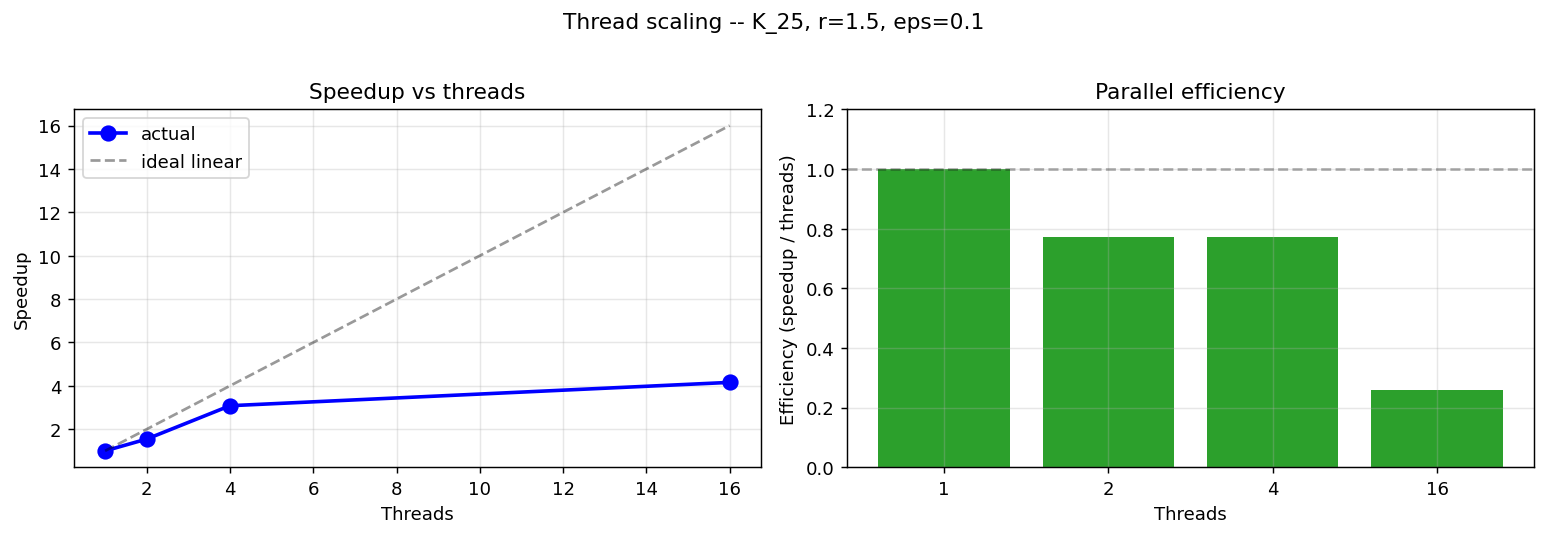

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df_threads['threads'], df_threads['speedup'], 'bo-', lw=2, ms=8, label='actual')
ax1.plot(df_threads['threads'], df_threads['threads'], 'k--', alpha=.4, label='ideal linear')
ax1.set(xlabel='Threads', ylabel='Speedup', title='Speedup vs threads')
ax1.legend()

ax2.bar(range(len(thread_counts)), df_threads['efficiency'], color='#2ca02c')
ax2.set_xticks(range(len(thread_counts)), labels=thread_counts)
ax2.axhline(1.0, color='k', ls='--', alpha=.3)
ax2.set(xlabel='Threads', ylabel='Efficiency (speedup / threads)',
        title='Parallel efficiency', ylim=(0, 1.2))
plt.suptitle(f'Thread scaling -- K_25, r=1.5, eps=0.1', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## 9. Amplifiers of selection (BD update)

Under Birth-Death, star and double star are **amplifiers**: they increase $\rho$ for $r > 1$ vs well-mixed (Lieberman, Hauert & Nowak 2005). Note: under Death-Birth dynamics these same graphs are suppressors.

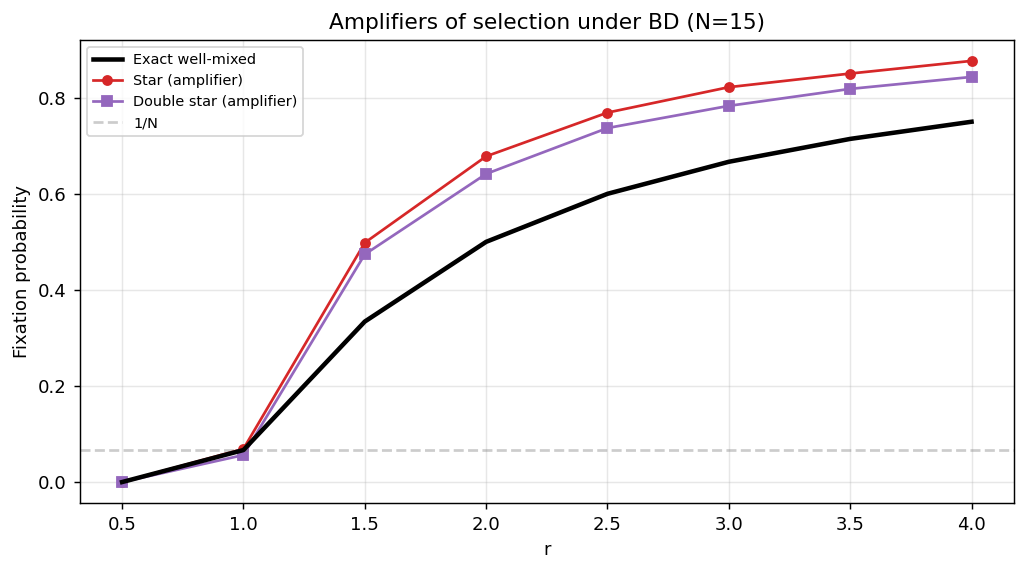

In [19]:
N = 15
r_grid = np.linspace(0.5, 4.0, 8)
exact_wm = [exact.well_mixed(N, float(r)) for r in r_grid]

star_est = [naive.estimate(star_graph(N), float(r), epsilon=0.15,
                           seed=42, num_threads=0).estimate for r in r_grid]
dbl_est  = [naive.estimate(double_star_graph(N // 2, N - N // 2), float(r), epsilon=0.15,
                           seed=42, num_threads=0).estimate for r in r_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(r_grid, exact_wm, 'k-', lw=2.5, label='Exact well-mixed', zorder=5)
ax.plot(r_grid, star_est, 'o-', ms=5, color=COLORS['star'], label='Star (amplifier)')
ax.plot(r_grid, dbl_est, 's-', ms=5, color=COLORS['dbl_star'], label='Double star (amplifier)')
ax.axhline(1/N, color='gray', ls='--', alpha=.4, label='1/N')
ax.set(xlabel='r', ylabel='Fixation probability',
       title=f'Amplifiers of selection under BD (N={N})')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 10. NetworkX / SciPy interop

`CSRGraph` converts to/from NetworkX graphs and SciPy CSR matrices, plus direct construction from numpy arrays.

In [20]:
# From NetworkX
G_pet = nx.petersen_graph()
g_petersen = CSRGraph.from_networkx(G_pet)
print(f'Petersen: {g_petersen}, {g_petersen.degree_stats()}')
print(f'rho(r=1.5) = {fixation_probability(g_petersen, 1.5)}')
print()

# From numpy arrays (src, dst pairs)
src = np.array([0, 1, 2, 3, 0], dtype=np.uint32)
dst = np.array([1, 2, 3, 4, 4], dtype=np.uint32)
g_path = CSRGraph(5, src, dst)
print(f'Path graph from arrays: {g_path}')
print(f'rho(r=1.5) = {naive.estimate(g_path, 1.5, seed=42)}')
print()

# Watts-Strogatz small-world
G_ws = nx.watts_strogatz_graph(20, 4, 0.3, seed=42)
g_ws = CSRGraph.from_networkx(G_ws)
res_ws = naive.estimate(g_ws, 1.5, epsilon=0.15, seed=42, num_threads=1)
print(f'Watts-Strogatz(20,4,0.3): {g_ws}')
print(f'rho(r=1.5) = {res_ws.estimate:.6f}  [{res_ws.method}]')
print()

# Barabasi-Albert preferential attachment
G_ba = nx.barabasi_albert_graph(20, 2, seed=42)
g_ba = CSRGraph.from_networkx(G_ba)
res_ba = naive.estimate(g_ba, 1.5, epsilon=0.15, seed=42, num_threads=1)
print(f'Barabasi-Albert(20,2): {g_ba}')
print(f'rho(r=1.5) = {res_ba.estimate:.6f}  [{res_ba.method}]')

Petersen: CSRGraph(vertices=10, edges=15), DegreeStats(min=3, max=3, avg=3.00, regular=True, edges=15)
rho(r=1.5) = FixationResult(estimate=0.339216, CI=[0.339216, 0.339216], method=exact_isothermal_regular, samples=0, elapsed=0.000s)

Path graph from arrays: CSRGraph(vertices=5, edges=5)
rho(r=1.5) = FixationResult(estimate=0.381997, CI=[0.34727, 0.424441], method=mc_naive, samples=3466, elapsed=0.002s)



Watts-Strogatz(20,4,0.3): CSRGraph(vertices=20, edges=40)
rho(r=1.5) = 0.340786  [Method.mc_naive]



Barabasi-Albert(20,2): CSRGraph(vertices=20, edges=36)
rho(r=1.5) = 0.394506  [Method.mc_naive]


In [21]:
# SciPy sparse roundtrip
import scipy.sparse as sp

A = g_petersen.to_scipy_sparse()
print(f'SciPy shape: {A.shape}, nnz: {A.nnz}, symmetric: {(A != A.T).nnz == 0}')

g_rt = CSRGraph.from_scipy_sparse(A)
print(f'Roundtrip:   {g_rt}, edges match: {g_rt.num_edges() == g_petersen.num_edges()}')

SciPy shape: (10, 10), nnz: 30, symmetric: True
Roundtrip:   CSRGraph(vertices=10, edges=15), edges match: True


## 11. Auto-selection API

`fixation_probability()` picks the best available algorithm:
$r=1 \to$ exact $1/N$, regular graph $\to$ isothermal formula, otherwise $\to$ naive MC.

In [22]:
cases = [
    ('K_20, r=1.0',     complete_graph(20), 1.0),
    ('cycle_20, r=1.5', cycle_graph(20),    1.5),
    ('star_15, r=2.0',  star_graph(15),     2.0),
]

auto_rows = []
for label, g, r in cases:
    res = fixation_probability(g, r, epsilon=0.1, seed=42)
    auto_rows.append({'case': label, 'estimate': f'{res.estimate:.6f}',
                      'method': str(res.method).split('.')[-1],
                      'samples': res.samples,
                      'time_s': f'{res.elapsed_seconds:.4f}'})
pd.DataFrame(auto_rows)

,case,estimate,method,samples,time_s
0,"K_20, r=1.0",0.050000,exact_r_equals_1,0,0.0000
1,"cycle_20, r=1.5",0.333434,exact_isothermal_regular,0,0.0000
2,"star_15, r=2.0",0.680367,mc_naive,31192,0.8566


## 12. Derived parameters

`diaz_naive(n, r, eps, delta)` computes sample count and step budget from Theorem 13.
`multiplicative_ci` gives the confidence interval for a given estimate.

In [23]:
params = _alg.params

# Sample count and step budget for different configurations
rows = []
for n in [10, 20, 50]:
    for eps in [0.1, 0.05]:
        p = params.diaz_naive(n, 1.5, epsilon=eps)
        rows.append({'n': n, 'epsilon': eps, 'samples': p.samples,
                     'step_limit_per_run': p.per_run_step_limit})
pd.DataFrame(rows)

,n,epsilon,samples,step_limit_per_run
0,10,0.10,13863,120000
1,10,0.05,55452,120000
2,20,0.10,55452,1920000
3,20,0.05,221808,1920000
4,50,0.10,346574,75000000
5,50,0.05,1386295,75000000


## 13. FixationResult API

In [24]:
res = naive.estimate(complete_graph(20), 2.0, epsilon=0.1, seed=42, num_threads=1)
print(res)
print()

# All fields
for attr in ['estimate', 'ci_lower', 'ci_upper', 'method',
             'epsilon', 'delta', 'samples', 'steps_total', 'steps_effective',
             'runs_aborted', 'elapsed_seconds', 'seed_used']:
    print(f'  {attr:20s} = {getattr(res, attr)}')

print()

# float() conversion and multiplicative CI
print(f'float(res) = {float(res):.6f}')
ci = params.multiplicative_ci(res.estimate, res.epsilon)
print(f'multiplicative_ci    = [{ci[0]:.6f}, {ci[1]:.6f}]')
print()

# to_dict() for serialization
pd.DataFrame([res.to_dict()])

FixationResult(estimate=0.499026, CI=[0.45366, 0.554474], method=mc_naive, samples=55452, elapsed=0.970s)

  estimate             = 0.499026184808483
  ci_lower             = 0.45366016800771175
  ci_upper             = 0.5544735386760922
  method               = Method.mc_naive
  epsilon              = 0.1
  delta                = 0.25
  samples              = 55452
  steps_total          = 4847392
  steps_effective      = 1499074
  runs_aborted         = 0
  elapsed_seconds      = 0.970294676
  seed_used            = 42

float(res) = 0.499026
multiplicative_ci    = [0.453660, 0.554474]



,estimate,ci_lower,ci_upper,method,epsilon,delta,samples,steps_total,steps_effective,runs_aborted,elapsed_seconds,seed_used
0,0.499026,0.45366,0.554474,mc_naive,0.1,0.25,55452,4847392,1499074,0,0.970295,42


## 14. Error handling

In [25]:
from moran import InvalidInputError

cases = []

try: naive.estimate(complete_graph(10), 0.0)
except InvalidInputError as e: cases.append(('r = 0', str(e)))

try: naive.estimate(complete_graph(10), float('nan'))
except InvalidInputError as e: cases.append(('r = NaN', str(e)))

try:
    src = np.array([0, 2], dtype=np.uint32)
    dst = np.array([1, 3], dtype=np.uint32)
    naive.estimate(CSRGraph(4, src, dst), 1.5)
except InvalidInputError as e: cases.append(('disconnected', str(e)))

try: naive.estimate(complete_graph(10), 1.5, epsilon=0.0)
except ValueError as e: cases.append(('eps = 0', str(e)))

try: naive.estimate(complete_graph(10), 1.5, delta=0.0)
except ValueError as e: cases.append(('delta = 0', str(e)))

pd.DataFrame(cases, columns=['trigger', 'message'])

,trigger,message
0,r = 0,InvalidFitness: Fitness r must be finite and p...
1,r = NaN,InvalidFitness: Fitness r must be finite and p...
2,disconnected,InvalidGraph: Graph is not connected
3,eps = 0,"epsilon must be in (0, 1), got 0"
4,delta = 0,"delta must be in (0, 1), got 0"
